In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# loading the dataset and reading it into a pandas DataFrame
df = pd.read_csv('data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
# Filtering the DataFrame for Data Analyst jobs in India
df_In = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')]

# Dropping rows with missing salary information
df_In = df_In.dropna(subset=['salary_year_avg'])

# Exploding the 'job_skills' column to create a new row for each skill
df_In_exploded = df_In.explode('job_skills')

df_In_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


To find the count of skills and also the median salary for each skill.

In [4]:
# Using groupby to aggregate the data by 'job_skills' and calculate the count and median of 'salary_year_avg'.
df_DA_skills = df_In_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

# Renaming the columns for clarity
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_In)  # Find count of Data Analyst jobs in India with salary info

# Calculating the percentage of each skill relative to the total number of Data Analyst jobs in India
df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

df_DA_skills = df_DA_skills[df_DA_skills['skill_count'] > 0] # Filter out skills with zero occurrences

df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,96050.0,48.936170
excel,39,98500.0,41.489362
python,36,96050.0,38.297872
tableau,20,108087.5,21.276596
r,18,79200.0,19.148936
...,...,...,...
unify,1,79200.0,1.063830
unreal,1,105650.0,1.063830
visio,1,119250.0,1.063830


In [5]:
# Setting a threshold for skill demand
skill_limit = 5

# Filtering the DataFrame to include only skills that are in high demand (above the skill_limit)
df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_limit]

###  Strategic Skill Optimization (Demand vs. Pay)
This section maps out the most optimal specializations for Data Analysts in India by calculating the intersection of overall skill demand (job prevalence %) and economic valuation (median yearly salary). The resulting scatter plot acts as a strategic guide to identify entry-level standards and high-value upskilling frameworks.
Plotting the scatter plot for skills in high demand.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


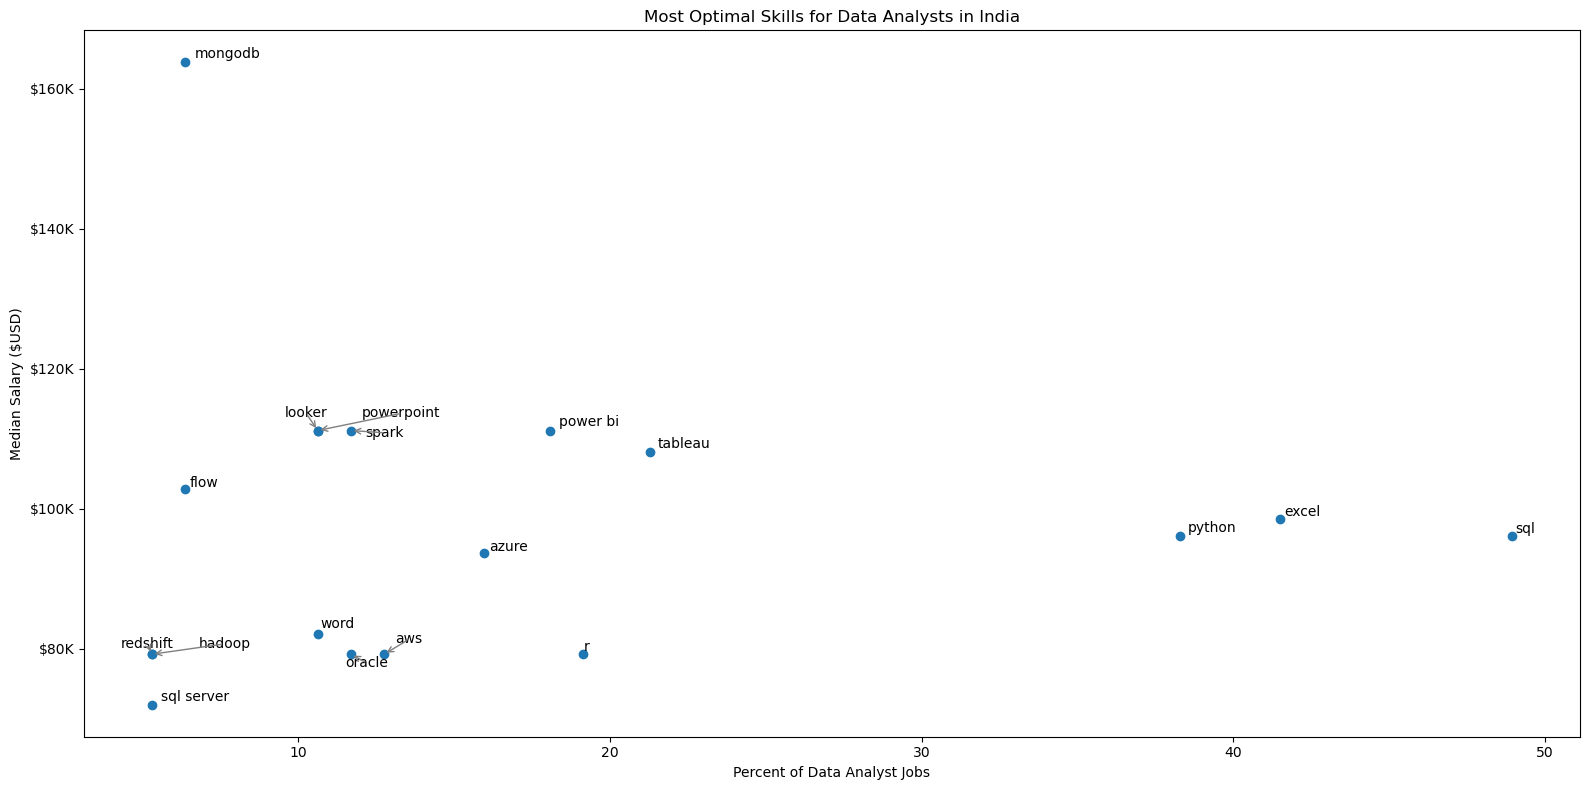

In [6]:
from adjustText import adjust_text

plt.figure(figsize=(16,8)) # Set the figure size
plt.scatter(df_DA_skills_high_demand['skill_percent'], df_DA_skills_high_demand['median_salary']) # Create a scatter plot of skill percentage vs median salary
plt.xlabel('Percent of Data Analyst Jobs')                      # Set the x-axis label
plt.ylabel('Median Salary ($USD)')                              # Set the y-axis label
plt.title('Most Optimal Skills for Data Analysts in India')     # Set the title of the plot

# Format y-axis as $K
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')) # Format the y-axis ticks as $K

# Collect labels into texts list (for adjust_text)
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):    # Loop through each skill in the high demand skills DataFrame
    x = df_DA_skills_high_demand['skill_percent'].iloc[i]   # Get the skill percentage for the current skill
    y = df_DA_skills_high_demand['median_salary'].iloc[i]   # Get the median salary for the current skill
    texts.append(plt.text(x, y, txt))                       

# Adjust text positions to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray'),         # Set arrow properties for the text labels
    expand_points=(1.2, 1.2),                               # Set expansion for points to avoid overlap
    expand_text=(1.2, 1.2),                                 # Set expansion for text to avoid overlap
    force_points=0.5,                                       # Set force for points to avoid overlap
    force_text=0.5                                          # Set force for text to avoid overlap
)

plt.tight_layout()
plt.show() 

In [7]:
# Creating the 'df_technology' DataFrame by copying the 'job_type_skills' column from the original DataFrame
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}                            # initialize an empty dictionary to store the combined technology skills
for row in df_technology:                       # iterate through each row in the 'df_technology' DataFrame
    row_dict = ast.literal_eval(row)            # convert the string representation of the dictionary in the current row to an actual dictionary
    for key, value in row_dict.items():         # iterate through each key-value pair in the current dictionary
        if key in technology_dict:              # check if the key already exists in the combined dictionary
            technology_dict[key] += value       # if the key exists, append the values to the existing list of values for that key
        else:
            technology_dict[key] = value        # if the key does not exist, create a new key-value pair in the combined dictionary

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():      # iterate through each key-value pair in the combined dictionary
    technology_dict[key] = list(set(value))     # convert the list of values for the current key to a set (to remove duplicates) and then back to a list

technology_dict

{'analyst_tools': ['sas',
  'msaccess',
  'sap',
  'dax',
  'sharepoint',
  'cognos',
  'visio',
  'powerpoint',
  'excel',
  'splunk',
  'outlook',
  'looker',
  'ssis',
  'spss',
  'tableau',
  'alteryx',
  'ssrs',
  'power bi',
  'powerbi',
  'nuix',
  'ms access',
  'sheets',
  'word',
  'qlik',
  'datarobot',
  'esquisse',
  'spreadsheet',
  'microstrategy'],
 'programming': ['sas',
  'visual basic',
  'r',
  'swift',
  'assembly',
  'scala',
  'sql',
  'pascal',
  'mongodb',
  'php',
  'erlang',
  'perl',
  'kotlin',
  'vba',
  'dart',
  'rust',
  'fortran',
  'javascript',
  'crystal',
  'objective-c',
  'powershell',
  'golang',
  'c',
  'solidity',
  'delphi',
  'nosql',
  'css',
  'haskell',
  'mongo',
  'sass',
  'ocaml',
  'apl',
  'no-sql',
  'lua',
  'ruby',
  'visualbasic',
  'c++',
  'c#',
  'f#',
  'vb.net',
  'go',
  'clojure',
  'typescript',
  'cobol',
  'java',
  'elixir',
  't-sql',
  'bash',
  'matlab',
  'groovy',
  'lisp',
  'python',
  'shell',
  'html',
  'ju

In [8]:
# Creating a DataFrame from the technology_dict to analyze the technology skills required for Data Analyst jobs in India
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills']) # Create DataFrame from the combined technology skills dictionary

df_technology = df_technology.explode('skills') # Explode the 'skills' column to separate each skill into its own row

df_technology

,technology,skills
0,analyst_tools,sas
0,analyst_tools,msaccess
0,analyst_tools,sap
0,analyst_tools,dax
0,analyst_tools,sharepoint
...,...,...
9,sync,google chat
9,sync,slack
9,sync,mattermost
9,sync,unify


In [9]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills') # Merge the two DataFrames on the 'job_skills' and 'skills' columns

df_DA_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,46,96050.0,48.936170,programming,sql
1,39,98500.0,41.489362,analyst_tools,excel
2,36,96050.0,38.297872,programming,python
3,20,108087.5,21.276596,analyst_tools,tableau
4,18,79200.0,19.148936,programming,r
...,...,...,...,...,...
80,1,79200.0,1.063830,sync,unify
81,1,105650.0,1.063830,other,unreal
82,1,119250.0,1.063830,analyst_tools,visio
83,1,79200.0,1.063830,os,windows


In [10]:
# Filter the DataFrame to include only rows where the skill percentage is greater than the specified limit
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percent'] > skill_limit]

In [11]:
# Standardize skill names
df_DA_skills_tech_high_demand['skills'] = df_DA_skills_tech_high_demand['skills'].str.strip().str.lower()

# Drop duplicates
df_DA_skills_tech_high_demand = df_DA_skills_tech_high_demand.drop_duplicates(subset=['skills', 'skill_percent', 'median_salary'])

Create a scatter plot to visualize the relationship between skill percentage and median salary for high demand skills.

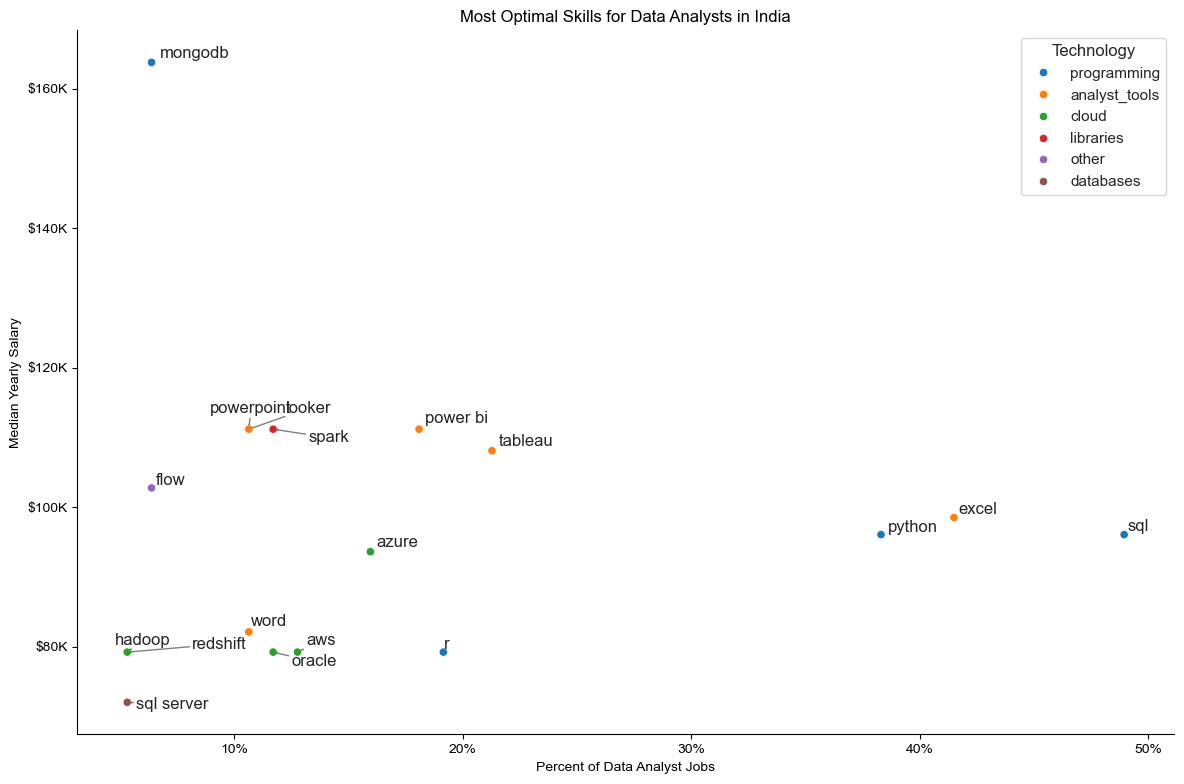

In [12]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(12,8)) # Set the figure size

sns.scatterplot(
    data=df_DA_skills_tech_high_demand,  # Filtered DataFrame with high-demand skills
    x='skill_percent',                   # x-axis variable representing the percentage of Data Analyst jobs requiring the skill
    y='median_salary',                   # y-axis variable representing the median salary for the skill
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_tech_high_demand.skills):  # Loop through each skill in the high demand skills DataFrame
    texts.append(plt.text(df_DA_skills_tech_high_demand['skill_percent'].iloc[i], df_DA_skills_tech_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))  

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')                          # Set the x-axis label
plt.ylabel('Median Yearly Salary')                                  # Set the y-axis label
plt.title('Most Optimal Skills for Data Analysts in India')         # Set the title of the plot
plt.legend(title='Technology')                                      # Set the legend title


ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Format the y-axis ticks as $K
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))                          # Format the x-axis ticks as percentages with no decimal places

# Adjust layout and display plot
plt.tight_layout()
plt.show()